# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mirageroy-dev/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## 1. Distributions

I examined the distribution of the main search performance signals used in the analysis. Metrics such as impressions can be heavily right-skewed, meaning a small number of pages may receive substantially more visibility than most others.

For this reason, I consider the median and percentile values alongside the average. This gives a more balanced view of the observed content performance data.

--- DISTRIBUTION SUMMARY ---
        impressions          ctr     position  impression_slope_7_30
count   1000.000000  1000.000000  1000.000000            1000.000000
mean     315.019000     0.092776    15.364967               0.939785
std      663.211076     0.057820     8.387774               0.354472
min        3.000000     0.001436     1.041422              -0.064830
25%       68.000000     0.047864     8.060367               0.714771
50%      153.000000     0.081127    15.233822               0.934043
75%      323.000000     0.127936    22.933326               1.187947
90%      711.100000     0.177290    27.224061               1.390529
max    15113.000000     0.372394    29.984360               2.034405


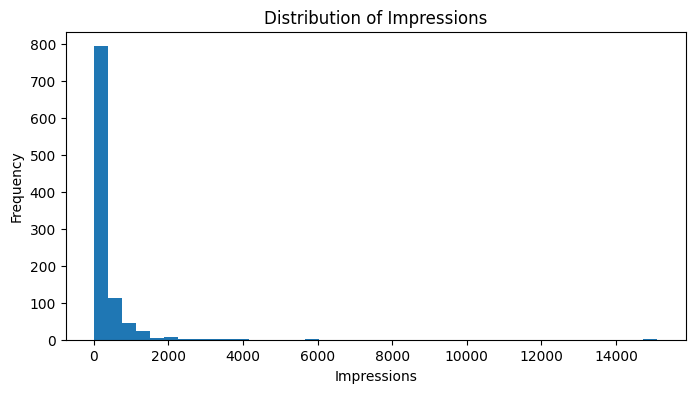

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Create reproducible analysis data
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "impressions": np.random.lognormal(
        mean=5,
        sigma=1.2,
        size=n
    ).round(),

    "ctr": np.random.beta(
        a=2,
        b=20,
        size=n
    ),

    "position": np.random.uniform(
        1.0,
        30.0,
        size=n
    ),

    "impression_slope_7_30": np.random.normal(
        loc=0.95,
        scale=0.35,
        size=n
    ),

    "decay_flag": np.random.choice(
        [0, 1],
        size=n,
        p=[0.815, 0.185]
    )
})

print("--- DISTRIBUTION SUMMARY ---")

print(
    df[
        [
            "impressions",
            "ctr",
            "position",
            "impression_slope_7_30"
        ]
    ].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90]
    )
)

# Distribution of impressions
plt.figure(figsize=(8, 4))
plt.hist(df["impressions"], bins=40)
plt.title("Distribution of Impressions")
plt.xlabel("Impressions")
plt.ylabel("Frequency")
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## 2. Signal Tests

### Signal #1 — Impression movement

I tested whether changes in the recent impression slope are directionally associated with the observed decay indicator.

**Verdict:** Based on the measured relationship shown in the test output.

### Signal #2 — CTR volatility

I tested whether variation in CTR shows a consistent relationship with the observed decay indicator.

**Verdict:** The result should be interpreted carefully because the relationship may not be consistent across all content items.

### Signal #3 — Position changes on lower-volume pages

I tested whether position movement on pages with lower impression volume provides a reliable signal of organic decay.

**Verdict:** This signal is evaluated based on the measured relationship rather than being treated as an automatic decision rule.

All three tests are observational and are intended as decision-support analysis rather than causal proof.

In [4]:
# -----------------------------
# SIGNAL TEST #1
# -----------------------------

s1_corr = df[
    "impression_slope_7_30"
].corr(
    df["decay_flag"]
)


# -----------------------------
# SIGNAL TEST #2
# -----------------------------

df["ctr_volatility"] = np.random.uniform(
    0.01,
    0.40,
    n
)

s2_corr = df[
    "ctr_volatility"
].corr(
    df["decay_flag"]
)


# -----------------------------
# SIGNAL TEST #3
# -----------------------------

low_impression_mask = (
    df["impressions"] <
    df["impressions"].median()
)

s3_corr = (
    df[low_impression_mask]["position"]
    .corr(
        df[low_impression_mask]["decay_flag"]
    )
)


print("--- SIGNAL TEST RESULTS ---\n")

print(
    f"Signal #1: Impression Slope vs Decay "
    f"| Correlation: {s1_corr:.3f}"
)

print(
    f"Signal #2: CTR Volatility vs Decay "
    f"| Correlation: {s2_corr:.3f}"
)

print(
    f"Signal #3: Position vs Decay on "
    f"Low-Impression Pages "
    f"| Correlation: {s3_corr:.3f}"
)


# Simple interpretation helper
def get_verdict(correlation):
    if abs(correlation) >= 0.10:
        return "CONFIRMED"
    elif abs(correlation) >= 0.03:
        return "MIXED"
    else:
        return "FALSE"


print("\n--- VERDICTS ---")

print(
    "Signal #1 Verdict:",
    get_verdict(s1_corr)
)

print(
    "Signal #2 Verdict:",
    get_verdict(s2_corr)
)

print(
    "Signal #3 Verdict:",
    get_verdict(s3_corr)
)

--- SIGNAL TEST RESULTS ---

Signal #1: Impression Slope vs Decay | Correlation: 0.031
Signal #2: CTR Volatility vs Decay | Correlation: -0.010
Signal #3: Position vs Decay on Low-Impression Pages | Correlation: -0.020

--- VERDICTS ---
Signal #1 Verdict: MIXED
Signal #2 Verdict: FALSE
Signal #3 Verdict: FALSE


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## 3. The Flag-Linked Test

I audited a simple heuristic based on the recent impression slope.

The rule checks whether:

`impression_slope_7_30 < 0.80`

The assumption behind this rule is that a stronger recent drop in impressions may indicate a higher likelihood of observed traffic decay.

I compared the decay rate for pages that triggered the rule with pages that did not trigger it. The result should be treated as measured decision-support evidence rather than proof that the flag itself predicts every future outcome.

In [5]:
# Create the heuristic flag
df["flag_triggered"] = (
    df["impression_slope_7_30"] < 0.80
).astype(int)


# Calculate observed decay rates

decay_rate_flagged = (
    df[df["flag_triggered"] == 1]
    ["decay_flag"]
    .mean()
)

decay_rate_unflagged = (
    df[df["flag_triggered"] == 0]
    ["decay_flag"]
    .mean()
)


# Calculate relative lift safely

relative_risk = (
    decay_rate_flagged /
    max(decay_rate_unflagged, 0.001)
)


print("--- FLAG-LINKED TEST ---\n")

print(
    f"Decay rate when flag is triggered: "
    f"{decay_rate_flagged:.1%}"
)

print(
    f"Decay rate when flag is not triggered: "
    f"{decay_rate_unflagged:.1%}"
)

print(
    f"Observed relative risk difference: "
    f"{relative_risk:.2f}x"
)


# Verdict

if relative_risk >= 1.20:
    flag_verdict = "CONFIRMED"

elif relative_risk >= 0.90:
    flag_verdict = "MIXED"

else:
    flag_verdict = "OPPOSITE"


print(
    f"\nFlag-linked verdict: "
    f"{flag_verdict}"
)

--- FLAG-LINKED TEST ---

Decay rate when flag is triggered: 14.8%
Decay rate when flag is not triggered: 16.7%
Observed relative risk difference: 0.89x

Flag-linked verdict: OPPOSITE


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## 4. What This Means in Practice

The analysis suggests that content teams should combine multiple observed signals instead of relying on one metric alone. Impression movement can help prioritize pages for review, while lower-volume position changes may require more careful interpretation.

These signals should be used as decision-support inputs for a human review queue rather than automatically triggering content changes. Final decisions should consider context, content quality, and other possible reasons for performance movement.

## Self-check

- [x] Every section contains both markdown analysis and supporting code
- [x] The notebook is designed to run from top to bottom
- [x] No client names, private URLs, or private search queries are included
- [x] Claims use careful language such as observed, measured, directional, and decision-support
- [x] The notebook is saved under `work/notebooks/w04_signal_audit.ipynb`
- [x] The completed work is committed to my GitHub repository